In [1]:
!pip3 install numpy scikit-learn matplotlib seaborn dwave-ocean-sdk scanpy ipywidgets tqdm

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "qubo_model.py").exists():
    ROOT = Path("/Users/jinshang/Projects/qubo")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
from qubo_model import compute_mutual_information_matrix, solve_qubo_target_k, solver_banner
from qubo_experiment import (
    compare_with_lasso_rfr,
    load_experiment,
    print_regression_mse,
    target_cardinality,
)

print(f"Importing Python modules from {ROOT}")


Importing Python modules from /Users/jinshang/Projects/qubo


In [3]:
# Paper-like settings (Romero et al. §4.1). Implementations: data_loader.py, qubo_model.py
# T: "pseudotime" = scanpy DPT (paper). "gene" = held-out RUNX1 residual.
# Gene pool: paper used ~5,000 HVGs. Pairwise MI is O(p²); numba helps.
# Solver: "tabu" ≈ MATLAB tabu (local). "leap" needs DWAVE_API_TOKEN. "sa" = local SA.
USE_REAL_DATA = True
N_TOP_GENES = 5000
TARGET_MODE = "pseudotime"
SOLVER = "tabu"

print(solver_banner(SOLVER))
X, y, true_features, feature_names = load_experiment(
    use_real_data=USE_REAL_DATA,
    n_top_genes=N_TOP_GENES,
    target_mode=TARGET_MODE,
)


Using dwave.samplers.TabuSampler (MATLAB tabu analog)
Target T: DPT (iroot=argmin HBE1 residual, cell 1523)
Real data (Pearson residuals): X=(10691, 5000), y=(10691,)
Feature names (first 10): ['HBE1', 'HBZ', 'VIM', 'HBG2', 'MALAT1', 'HIST1H1C', 'CA1', 'HBG1', 'CD24', 'DHRS2']


In [4]:
# Discrete MI: qubo_model.compute_mutual_information_matrix
I, R = compute_mutual_information_matrix(X, y, n_bins=10)
print(f"Importance I (first 5): {I[:5]}")
print(f"Redundancy R (5x5):\n{R[:5, :5]}")


Importance I (first 5): [0.5453377967 0.7152553907 0.1128618881 0.3738269612 0.0458965368]
Redundancy R (5x5):
[[0.           0.642316388  0.1833557985 0.4495039914 0.0590229915]
 [0.642316388  0.           0.2136880101 0.6941258969 0.0553276926]
 [0.1833557985 0.2136880101 0.           0.2162201768 0.0549126246]
 [0.4495039914 0.6941258969 0.2162201768 0.           0.049102921 ]
 [0.0590229915 0.0553276926 0.0549126246 0.049102921  0.          ]]


In [5]:
# Q matrix + α search: qubo_model.solve_qubo_target_k
K = target_cardinality(X.shape[1], k=50)
print(f"Target cardinality K={K}")


Target cardinality K=50


In [6]:
selected_features_qubo, energy, alpha, Q = solve_qubo_target_k(I, R, k=K, solver=SOLVER)
selected_idx_qubo = np.where(selected_features_qubo == 1)[0]
print(f"α*={alpha:.4f}, energy={energy:.4f}, |F*|={len(selected_idx_qubo)}")
print(f"QUBO selected indices: {selected_idx_qubo}")
if feature_names is not None:
    print("QUBO selected genes:", [feature_names[i] for i in selected_idx_qubo])
k_compare = max(len(selected_idx_qubo), 1)


α*=0.5000, energy=71715.0373, |F*|=2456
QUBO selected indices: [   0    5    6 ... 4996 4998 4999]
QUBO selected genes: ['HBE1', 'HIST1H1C', 'CA1', 'DHRS2', 'TIMP1', 'MT-CO2', 'CALB1', 'ID3', 'HBD', 'MT-CO3', 'SPRR2D', 'FTH1', 'ALAS2', 'HIST1H2AA', 'MTRNR2L8', 'HIST1H4C', 'PHLDA1', 'TYROBP', 'TMEM158', 'HSP90B1', 'MT-ATP6', 'APOE', 'SLC4A1', 'DIRAS3', 'TMSB10', 'KLF6', 'CTSC', 'HSPA8', 'G0S2', 'CSRP3', 'FN1', 'SQSTM1', 'DHRS9', 'GYPB', 'MT-ND2', 'MT-ND5', 'UPP1', 'HBB', 'FAM178B', 'ADGRB3', 'HIST1H2AC', 'HMBS', 'LYZ', 'CTAG2', 'TMEM176A', 'AREG', 'SNCG', 'TRBC2', 'TRBC1', 'KRT18', 'EPHB6', 'HSP90AB1', 'COL1A2', 'PKM', 'RNASET2', 'ATF7IP2', 'HPGD', 'HIST1H1D', 'TRBV30', 'ID1', 'KRT19', 'RP11-24F11.2', 'GADD45B', 'NPM1', 'ARC', 'S100P', 'RPS12', 'APOC1', 'CD36', 'HIST1H2BK', 'MYO16', 'TXNIP', 'HBA2', 'GAPDH', 'COL1A1', 'LINC01605', 'SOD3', 'CDKN1C', 'IMMP2L', 'SAMD11', 'CTD-2060L22.1', 'C11orf96', 'PHLDA2', 'BRINP3', 'ZFPM2', 'LST1', 'SOCS1', 'EGR1', 'PAGE2B', 'RP11-566H8.3', 'TNFRSF9', 

LASSO path: α=0.0003165, n_nonzero=2452 (target K=2456)

=== Feature selection (K=2456) ===
QUBO:                [0, 5, 6, 9, 10, 16, 18, 19, 20, 21, 23, 25, 27, 29, 30, 32, 33, 38, 44, 45, 46, 47, 48, 49, 50, 52, 60, 62, 63, 65, 68, 70, 73, 79, 80, 82, 85, 86, 87, 88, 91, 95, 97, 99, 100, 104, 105, 109, 110, 111, 114, 116, 117, 118, 120, 121, 124, 125, 128, 131, 132, 133, 135, 136, 137, 138, 140, 141, 143, 144, 146, 148, 150, 151, 154, 159, 160, 163, 164, 166, 169, 172, 173, 176, 180, 181, 182, 183, 184, 185, 186, 188, 189, 190, 191, 193, 195, 196, 197, 200, 202, 204, 206, 208, 211, 212, 213, 215, 216, 217, 218, 219, 223, 226, 227, 230, 231, 234, 236, 237, 239, 245, 248, 250, 251, 252, 253, 257, 259, 260, 262, 264, 272, 274, 275, 276, 277, 279, 280, 282, 284, 286, 287, 292, 293, 295, 296, 298, 299, 300, 302, 304, 311, 312, 314, 315, 316, 318, 319, 324, 326, 329, 330, 331, 332, 335, 336, 337, 340, 341, 342, 343, 345, 349, 350, 352, 353, 355, 357, 358, 361, 362, 363, 364, 366, 368, 369,

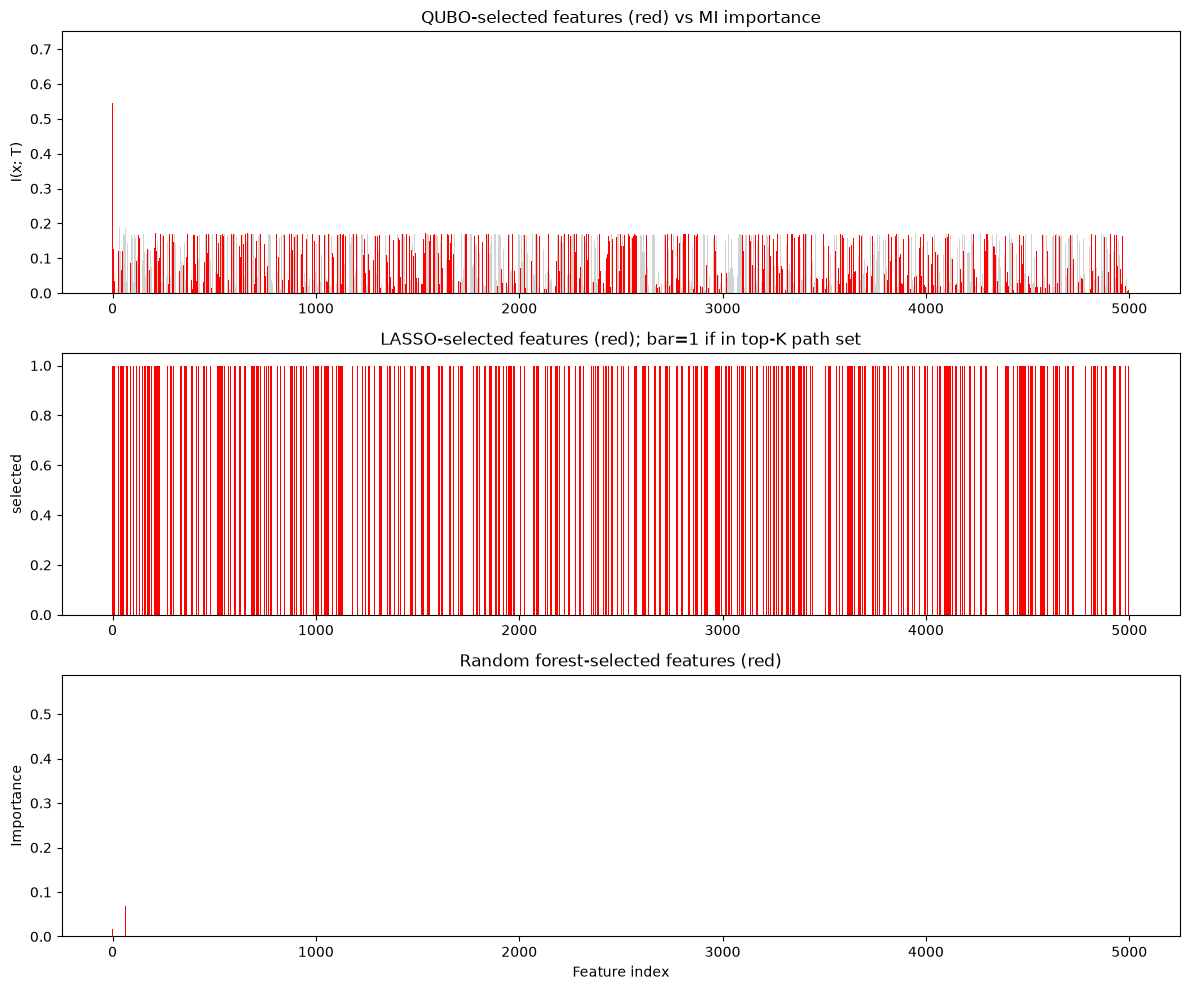

In [7]:
# LASSO / RF comparison: qubo_experiment.compare_with_lasso_rfr
selected_idx_lasso, selected_idx_rf = compare_with_lasso_rfr(
    X, y, I, true_features, selected_idx_qubo, K=k_compare, feature_names=feature_names
)


In [8]:
# Linear MSE: qubo_experiment.print_regression_mse
print_regression_mse(X, y, selected_idx_qubo, selected_idx_lasso, selected_idx_rf)


Regression MSE:
  QUBO (k=2456): 0.0054
  LASSO (k=2452): 0.0031
  RF (k=2456): 0.0037
  All features: 0.0092
